# Hypotesetesting og t-tester
*Data Mining & Analytics – Samling 2, dag 1 (forskningsmetode og statistiske tester)*



Vi tar utgangspunkt i eksempelet fra introforelesningen: to grupper får ulikt treningsprogram, hvor
gruppe 1 trener én gang i uka, gruppe 2 tre ganger i uka, og etter 12 uker måler vi hvor langt de løper på en 12-minutters test.

* **H₀**: forventet løpelengde er lik i de to gruppene
* **Hₐ**: gruppe 2 løper lenger enn gruppe 1 (ensidig test) / gruppene er ulike (tosidig test)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

## Simulere data

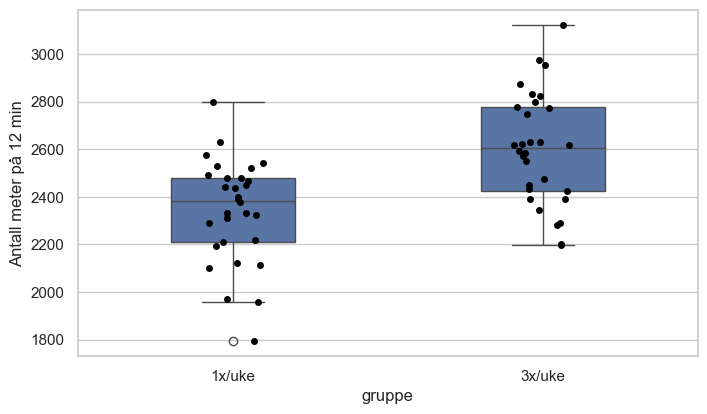

        count    mean    std
gruppe                      
1x/uke     30  2342.3  217.3
3x/uke     30  2598.8  235.8


In [2]:
rng = np.random.default_rng(7)
n = 30
g1 = rng.normal(2450, 260, n).round()     # 1 gang i uka
g2 = rng.normal(2600, 260, n).round()     # 3 ganger i uka 
df = pd.DataFrame({"gruppe": ["1x/uke"] * n + ["3x/uke"] * n, "meter": np.r_[g1, g2]})

sns.boxplot(data=df, x="gruppe", y="meter", width=0.4)
sns.stripplot(data=df, x="gruppe", y="meter", color="black")
plt.ylabel("Antall meter på 12 min")
plt.show()
print(df.groupby("gruppe")["meter"].agg(["count", "mean", "std"]).round(1))

## Student-t test

In [3]:
res = stats.ttest_ind(g2, g1, equal_var=True)           
print("Tosidig:", res.pvalue.round(6))

res = stats.ttest_ind(g2, g1, equal_var=True, alternative="greater")           
print("Ensidig:", res.pvalue.round(6))


Tosidig: 5e-05
Ensidig: 2.5e-05


 **Tips:** bruk Welch som standard (equal_var=False), den er trygg selv når variansene er like.

### Effektstørrelse: Cohens d
p-verdien sier noe om om det er en forskjel, men ikke hvor stor den er. 
Tommelfingerregel: 0.2 liten, 0.5 middels, 0.8 stor.

In [4]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2))
    return (np.mean(b) - np.mean(a)) / sp

print("Cohens d =", round(cohens_d(g1, g2), 2))

Cohens d = 1.13


## Paret t-test (samme person målt to ganger)

Datasett exercise: puls hos personer som løper, målt etter 1 og 30 minutter. Hver person er sin egen kontroll 

paret test
(tester om gjennomsnittet av *differansene* er 0).

In [11]:
df_ex = pd.read_csv("../Data/exercise.csv")
lop = df_ex[df_ex['kind']=="running"].pivot(index="id", columns="time", values="pulse")[["1 min", "30 min"]]
print(lop.T)
diff = lop["30 min"] - lop["1 min"]
print("Gjennomsnittlig økning:", diff.mean().round(1), "slag/min")
print(stats.ttest_rel(lop["30 min"], lop["1 min"]).pvalue)

id       21   22  23   24   25   26   27   28   29   30
time                                                   
1 min    93   98  98   87   94   95  100  103   94   99
30 min  110  112  99  120  116  143  140  140  130  150
Gjennomsnittlig økning: 29.9 slag/min
0.00022100433095826374


## Styrke (power) og utvalgsstørrelse

* **Type I-feil (α):** forkaster H₀ selv om den er sann.
* **Type II-feil (β):** beholder H₀ selv om den er usann. 
* **Power = 1 − β.**

Hvor mange trenger vi per gruppe for å oppdage d = 0,5 med 80 % power?

n per gruppe for d=0.5, 80 % power: 64.0
Power med n=30 per gruppe og d=0.5: 0.48


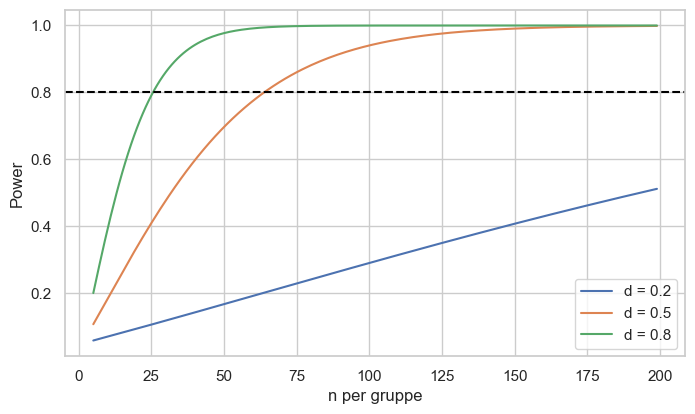

In [12]:
from statsmodels.stats.power import TTestIndPower
pw = TTestIndPower()
print("n per gruppe for d=0.5, 80 % power:", np.ceil(pw.solve_power(effect_size=0.5, alpha=0.05, power=0.8)))
print("Power med n=30 per gruppe og d=0.5:", round(pw.power(effect_size=0.5, nobs1=30, alpha=0.05), 2))

ns = np.arange(5, 200)
for d_ in [0.2, 0.5, 0.8]:
    plt.plot(ns, [pw.power(d_, n_, 0.05) for n_ in ns], label=f"d = {d_}")
plt.axhline(0.8, color="black", ls="--")
plt.xlabel("n per gruppe")
plt.ylabel("Power") 
plt.legend()
plt.show()